### Final Project  
**Chung-Chen, Huang** (ch3995)

# Future Risk of Humid Heat: Projected Changes in Global Heat Index Extremes

### Scientific Question
How will the Heat Index change across the globe under future warming, and which regions will become dangerously hot as warming continues?

High temperature alone does not capture how dangerous heat really is. Humidity plays a critical role by limiting the body's ability to cool through sweating. The Heat Index, developed by the National Weather Service (NWS), combines temperature and relative humidity into a single "feels-like" temperature that reflects actual heat stress on the human body. The NWS issues warnings at two key levels: a Heat Index of 40°C (105°F), where heat cramps, exhaustion, and heatstroke become likely with prolonged exposure, and 55°C (130°F), where heatstroke is considered very likely (NWS, 2024).

This project uses globally complete downscaled CMIP6 projections to map how the frequency and spatial extent of dangerous Heat Index levels evolve from the present into the late 21st century under different emission pathways.

**Thresholds**
- 40 °C  (105 °F)  —  NWS *Danger*
- 55 °C  (130 °F)  —  NWS *Extreme Danger*

**Models, scenarios, and periods**
- 6 NEX-GDDP-CMIP6 models: GFDL-ESM4, MPI-ESM1-2-HR, MRI-ESM2-0, ACCESS-CM2, EC-Earth3, CanESM5
- 1 historical baseline (1950–1980) + 2 SSP scenarios (SSP2-4.5, SSP5-8.5) at mid-century (2040–2060) and end-of-century (2080–2100)

### Python libraries and the NOAA/NWS Heat Index function
This project requires `numpy` and `matplotlib` (data analysis and plotting), `xarray` and `dask` (gridded climate data processing), `s3fs` (retrieving NEX-GDDP-CMIP6 data from AWS S3), `regionmask` (land masking), and `cartopy` (map projections). The Heat Index is implemented from the NOAA/NWS Rothfusz regression with the standard low-RH and high-RH adjustments (NWS, 2024).

In [3]:
import os, time
import pyproj
os.environ["PROJ_LIB"]  = pyproj.datadir.get_data_dir()
os.environ["PROJ_DATA"] = pyproj.datadir.get_data_dir()
import numpy as np
import xarray as xr
import dask
import s3fs
import regionmask
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from dask.diagnostics import ProgressBar


def _rothfusz(T_F, RH):
    return (-42.379
            + 2.04901523 * T_F
            + 10.14333127 * RH
            - 0.22475541 * T_F * RH
            - 6.83783e-3 * T_F**2
            - 5.481717e-2 * RH**2
            + 1.22874e-3 * T_F**2 * RH
            + 8.5282e-4 * T_F * RH**2
            - 1.99e-6 * T_F**2 * RH**2)

def heat_index(T_C, RH):
    """NOAA/NWS Heat Index (degC) from T (degC) and RH (%)."""
    T_F = np.asarray(T_C, dtype=float) * 9/5 + 32
    RH = np.asarray(RH, dtype=float)
    HI_F = _rothfusz(T_F, RH)

    low_mask = (RH < 13) & (T_F >= 80) & (T_F <= 112)
    low_adj = ((13 - RH) / 4) * np.sqrt(np.maximum((17 - np.abs(T_F - 95)) / 17, 0))
    HI_F = np.where(low_mask, HI_F - low_adj, HI_F)

    high_mask = (RH > 85) & (T_F >= 80) & (T_F <= 87)
    high_adj = ((RH - 85) / 10) * ((87 - T_F) / 5)
    HI_F = np.where(high_mask, HI_F + high_adj, HI_F)

    HI_F = np.where(T_F < 80, T_F, HI_F)
    return (HI_F - 32) * 5/9

### Reading NEX-GDDP-CMIP6 from S3, plus the land mask
Creating the functions to find the right yearly file on S3 (handling the `_v2.0` versioned files), to open multi-year time series with `xr.open_mfdataset`, and to build a land-only mask using Natural Earth coastlines via `regionmask`. The Heat Index analysis is restricted to land grid cells, since the NWS thresholds describe heat stress on the human body and it can great amount of time.

In [2]:
BUCKET = "s3://nex-gddp-cmip6/NEX-GDDP-CMIP6"
_FS = s3fs.S3FileSystem(anon=True)


def find_file(var, year, scenario, model, run, grid):
    """List S3 prefix and pick the right file for a given year, and make sure to pick version 2. 
    The address structure: https://nex-gddp-cmip6.s3.us-west-2.amazonaws.com/index.html#NEX-GDDP-CMIP6/ACCESS-CM2/historical/r1i1p1f1/tas/"""
    prefix = f"nex-gddp-cmip6/NEX-GDDP-CMIP6/{model}/{scenario}/{run}/{var}/"
    files = _FS.ls(prefix)
    target = str(year)
    matches = [f for f in files if f"_{target}.nc" in f or f"_{target}_" in f]
    if not matches:
        return None
    matches.sort(key=lambda x: ("_v" not in x, x))
    return f"s3://{matches[0]}"


def open_multiyear(var, years, scenario, model, run, grid):
    paths = [find_file(var, y, scenario, model, run, grid) for y in years]
    return xr.open_mfdataset(
        paths,
        engine="h5netcdf",
        chunks={"time": 90},
        storage_options={"anon": True, "default_cache_type": "first"},
        combine="by_coords",
        parallel=True,
    )

def get_land_mask(da_ref):
    land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
    return land.mask(da_ref.lon, da_ref.lat).notnull()

### Function for Computing exceedance days per model, scenario and period
For a given model, scenario, and year range, this routine downloads daily near-surface temperature (`tas`) and relative humidity (`hurs`), evaluates the Heat Index every day at every land grid cell, and counts the number of days per year that reach each NWS threshold. It writes one NetCDF file per configuration into `output_simple/`, containing both the per-year time series and the multi-year mean for each of the two thresholds. 

In [11]:
OUTPUT_DIR = "output_simple"

THRESHOLDS = [40, 55]

def compute_exceedance(model, scenario, years, grid, run="r1i1p1f1", overwrite=False):
    y0, y1 = min(years), max(years)
    fn = f"{OUTPUT_DIR}/{model}_{scenario}_{y0}-{y1}.nc"
    if os.path.exists(fn) and not overwrite:
        return xr.open_dataset(fn)
    """Two variables required for caculating Heatindex"""
    ds_tas  = open_multiyear("tas",  years, scenario, model, run, grid)
    ds_hurs = open_multiyear("hurs", years, scenario, model, run, grid)
    print(f"\n[{model} | {scenario} | {y0}-{y1}] opening files...", flush=True) 
    """Build a land mask from the grid and apply it to both variables — restrict the Heat Index to land only."""
    land = get_land_mask(ds_tas["tas"])
    T_C = (ds_tas["tas"] - 273.15).where(land)
    RH  = ds_hurs["hurs"].where(land)
    """Using defined heatindex function to get heatindex for each land grid cell"""
    HI = xr.apply_ufunc(heat_index, T_C, RH, dask="parallelized", output_dtypes=[np.float32])

    variables = {}
    for t in THRESHOLDS:
        """Count, per year and per land cell, how many days the Heat Index reaches threshold t."""
        annual = (HI >= t).groupby("time.year").sum("time")
        """Caculating and saving Period-averaged annual exceedance days and number of exceedance days"""
        variables[f"days_HI_ge_{t}_annual"] = annual.astype("float32")
        variables[f"days_HI_ge_{t}_mean"]   = annual.mean("year").astype("float32")

    print("  computing...", flush=True)
    
    t0 = time.time()
    with ProgressBar():
        computed = dask.compute(*variables.values())
    print(f"  done in {(time.time()-t0)/60:.1f} min", flush=True)

    ds = xr.Dataset(variables).compute() 
    print(f"  done in {(time.time()-t0)/60:.1f} min", flush=True) 
    ds.to_netcdf(fn) 
    return dss

### Batch processing: 6 CMIP6 models × 5 (scenario, period) configurations
The runner is applied to each of the six NEX-GDDP-CMIP6 models across one historical baseline (1950–1980) and four future configurations — mid-century (2040–2060) and end-of-century (2080–2100) under both SSP2-4.5 and SSP5-8.5 — for 30 NetCDF outputs in total. Each configuration is independent, so any failure is logged and the loop continues.

In [4]:
MODELS = {
    "GFDL-ESM4":     "gr1",
    "MPI-ESM1-2-HR": "gn",
    "MRI-ESM2-0":    "gn",
    "ACCESS-CM2":    "gn",
    "EC-Earth3":     "gr",
    "CanESM5":       "gn",
}

CONFIGS = [
    ("historical", range(1950, 1981)),
    ("ssp245",     range(2040, 2061)),
    ("ssp585",     range(2040, 2061)),
    ("ssp245",     range(2080, 2101)),
    ("ssp585",     range(2080, 2101)),
]

for model, grid in MODELS.items():
    for scenario, years in CONFIGS:
        try:
            compute_exceedance(model, scenario, years, grid)
        except Exception as e:
            print(f"[FAIL] {model} | {scenario} | {min(years)}-{max(years)}: {e}")


[ACCESS-CM2 | ssp585 | 2080-2100] opening files...
  computing...
[########################################] | 100% Completed | 36m 37s
  done in 36.6 min

[EC-Earth3 | historical | 1950-1980] opening files...
  computing...
[########################################] | 100% Completed | 55m 21s
  done in 55.4 min

[EC-Earth3 | ssp245 | 2040-2060] opening files...
  computing...
[########################################] | 100% Completed | 36m 21s
  done in 36.4 min

[EC-Earth3 | ssp585 | 2040-2060] opening files...
  computing...
[########################################] | 100% Completed | 37m 4ss
  done in 37.1 min

[EC-Earth3 | ssp245 | 2080-2100] opening files...
  computing...
[########################################] | 100% Completed | 36m 8ss
  done in 36.1 min

[EC-Earth3 | ssp585 | 2080-2100] opening files...
  computing...
[########################################] | 100% Completed | 36m 7ss
  done in 36.1 min

[CanESM5 | historical | 1950-1980] opening files...
  computing.

### Figure 1: Baseline Heat Index exceedance (1950–1980)
Model ensemble mean of the number of days per year on which the daily Heat Index reaches the NWS *Danger* (≥ 40 °C) and *Extreme Danger* (≥ 55 °C) thresholds, averaged across the six CMIP6 models over the historical baseline period. This provides the historical baseline reference against which the future panels are compared.

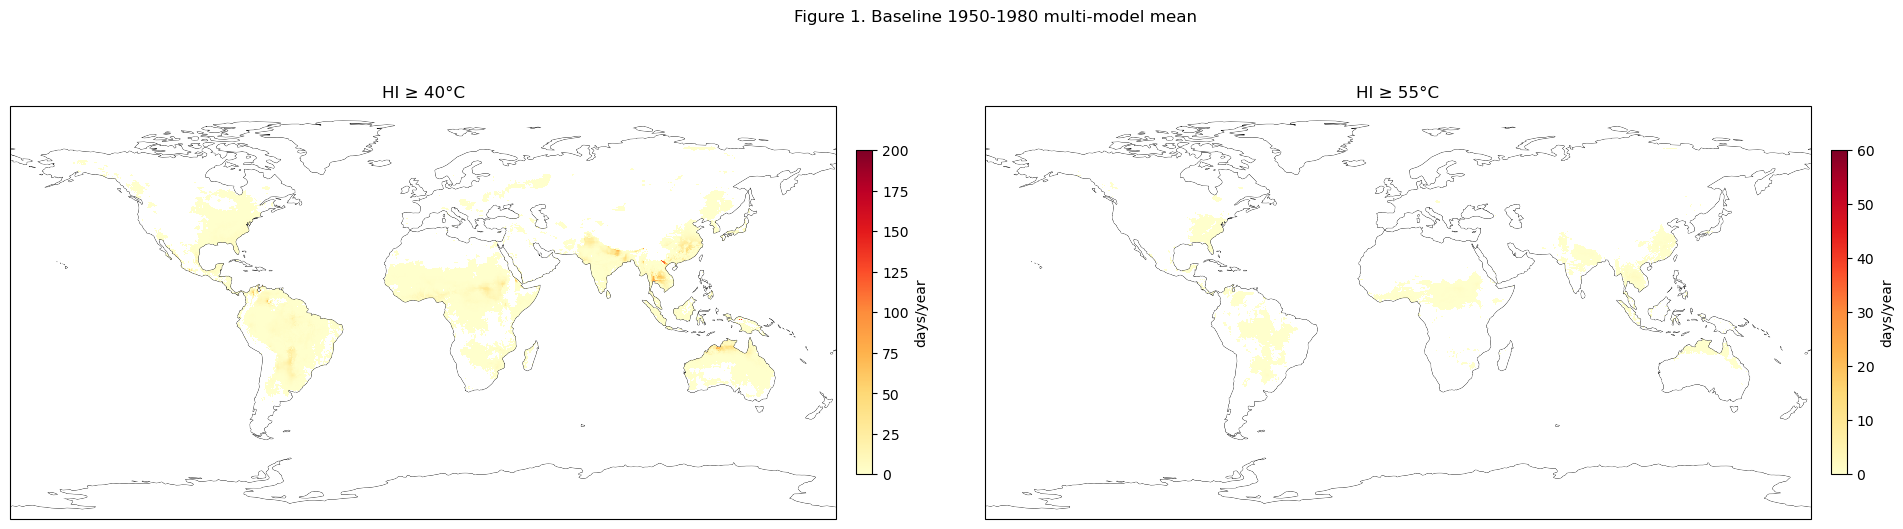

In [32]:
# Figure 1: baseline 1950-1980 multi-model mean
import glob
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

y0, y1 = 1950, 1980
files = sorted(glob.glob(f"Final_project/output_simple/*_historical_{y0}-{y1}.nc"))
ref = xr.open_dataset(files[0])
runs = [] 
for f in files: 
    ds = xr.open_dataset(f)                          
    ds = ds.interp(lat=ref.lat, lon=ref.lon)          
    runs.append(ds)
    
baseline = xr.concat(runs, dim="model").mean("model") # Using ensemble mean to lower the variability between models

fig, axes = plt.subplots(1, 2, figsize=(20, 6),
    subplot_kw={"projection": ccrs.PlateCarree()})

for i, t in enumerate([40, 55]):
    da = baseline[f"days_HI_ge_{t}_mean"]
    da = da.where(da > 0)
    vmax = 200 if t == 40 else 60
    da.plot(ax=axes[i], transform=ccrs.PlateCarree(),
            cmap="YlOrRd", vmin=0, vmax=vmax,
            cbar_kwargs={"label": "days/year", "orientation": "vertical", "shrink": 0.6, "pad":0.02})
    axes[i].add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    axes[i].coastlines(linewidth=0.5)
    axes[i].set_global()
    axes[i].set_title(f"HI ≥ {t}°C")

plt.suptitle("Figure 1. Baseline 1950-1980 multi-model mean")
plt.tight_layout()
plt.show()

### Figure 2: Mid-century Heat Index exceedance (2040–2060)
The same ensemble mean exceedance maps for mid-century, side by side under the moderate-mitigation SSP2-4.5 scenario and the high-emissions SSP5-8.5 scenario.

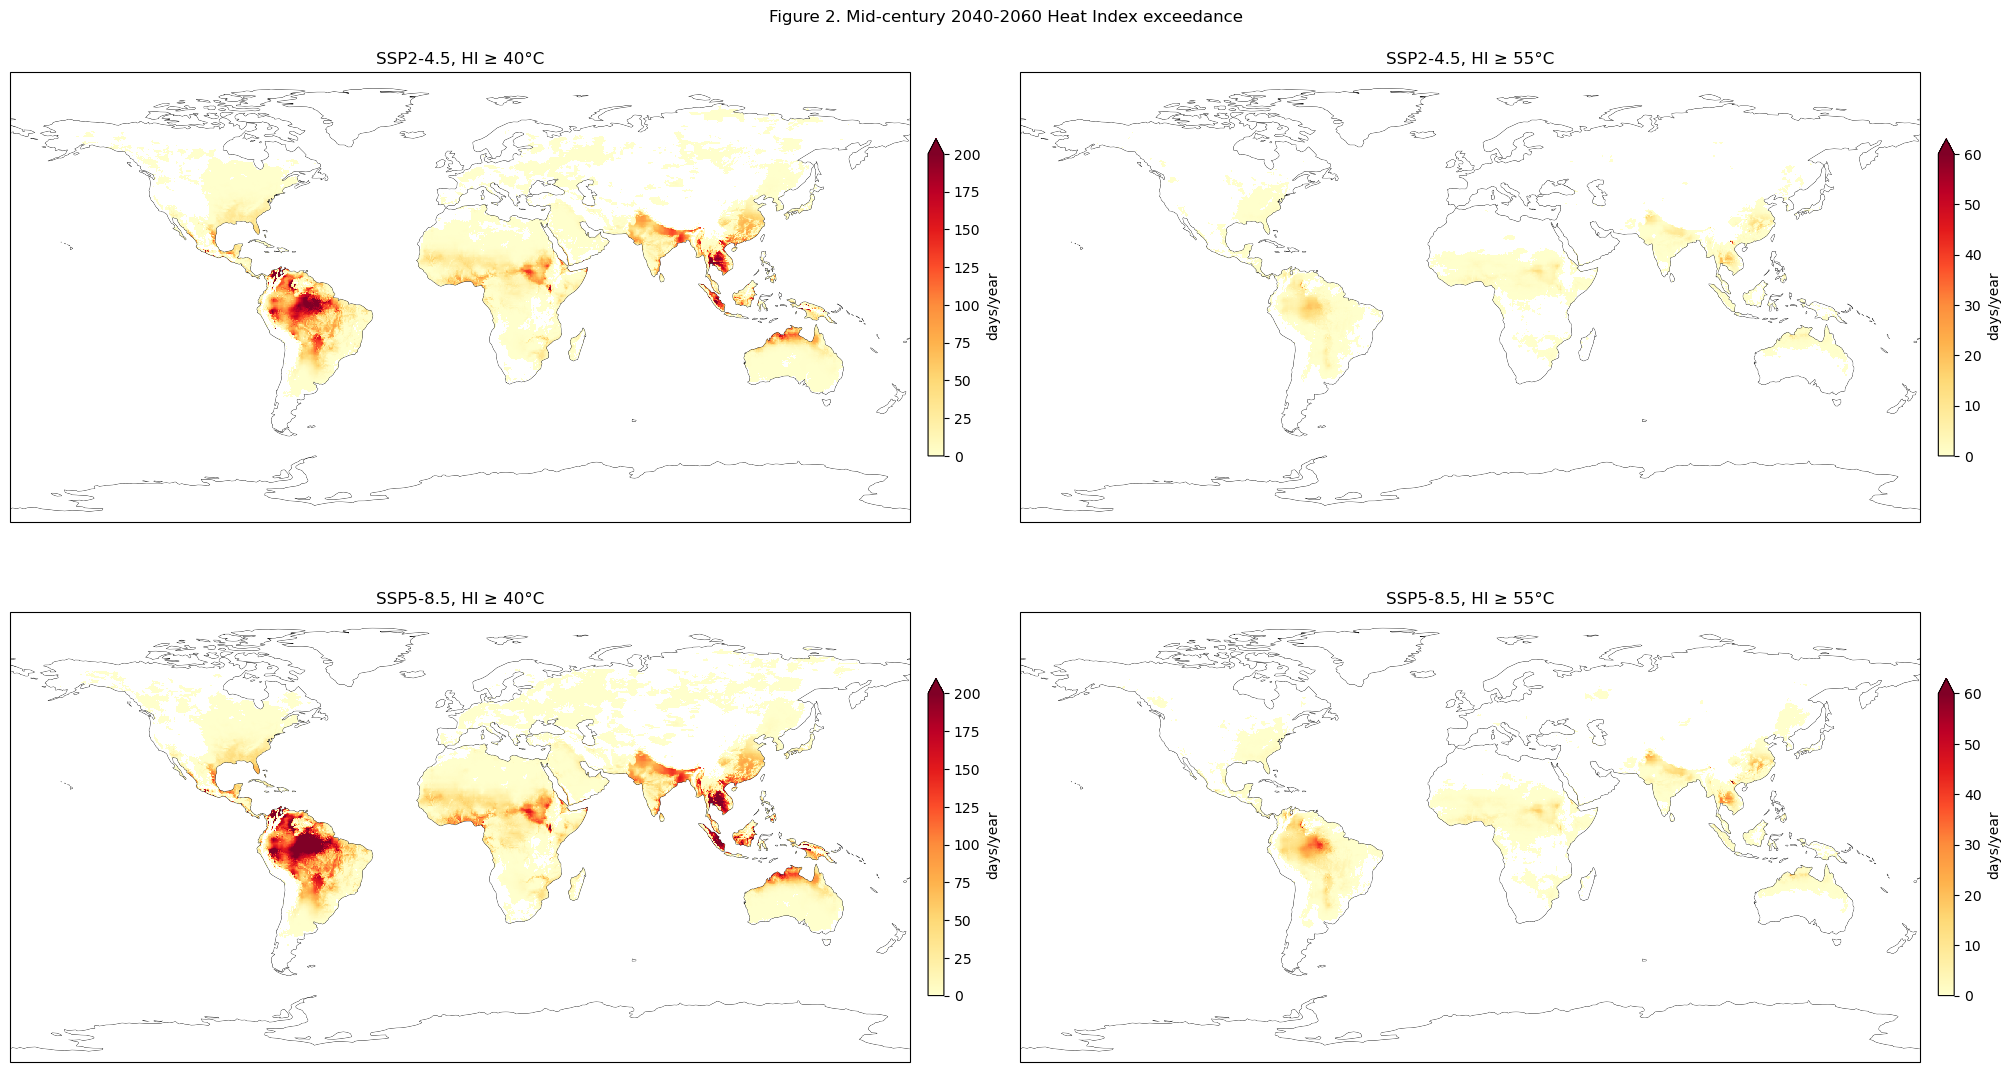

In [24]:
# Figure 2: mid-century 2040-2060 absolute days/year

import glob
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

y0, y1 = 2040, 2060

files_245 = sorted(glob.glob(f"Final_project/output_simple/*_ssp245_{y0}-{y1}.nc"))
ref = xr.open_dataset(files_245[0])
runs_245 = []
for f in files_245:
    ds = xr.open_dataset(f)
    ds = ds.interp(lat=ref.lat, lon=ref.lon)
    runs_245.append(ds)
mid_245 = xr.concat(runs_245, dim="model").mean("model")

# SSP5-8.5
files_585 = sorted(glob.glob(f"Final_project/output_simple/*_ssp585_{y0}-{y1}.nc"))
ref = xr.open_dataset(files_585[0])
runs_585 = []
for f in files_585:
    ds = xr.open_dataset(f)
    ds = ds.interp(lat=ref.lat, lon=ref.lon)
    runs_585.append(ds)
mid_585 = xr.concat(runs_585, dim="model").mean("model")

fig, axes = plt.subplots(2, 2, figsize=(20, 11),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)

for r, (label, ds) in enumerate([("SSP2-4.5", mid_245), ("SSP5-8.5", mid_585)]):
    for c, t in enumerate([40, 55]):
        da = ds[f"days_HI_ge_{t}_mean"]
        da = da.where(da > 0)
        vmax = 200 if t == 40 else 60
        da.plot(ax=axes[r, c], transform=ccrs.PlateCarree(),
                cmap="YlOrRd", vmin=0, vmax=vmax,
                cbar_kwargs={"label": "days/year", "orientation": "vertical", "shrink": 0.6, "pad":0.02})
        axes[r, c].add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
        axes[r, c].coastlines(linewidth=0.5)
        axes[r, c].set_global()
        axes[r, c].set_title(f"{label}, HI ≥ {t}°C")

plt.suptitle("Figure 2. Mid-century 2040-2060 Heat Index exceedance")
plt.show()

### Figure 3: Mid-century change in Heat Index exceedance relative to baseline
Difference (mid-century minus historical baseline) in the average number of exceedance days per year, highlighting where dangerous humid heat begins to emerge or intensify by 2040–2060 under each SSP scenario.

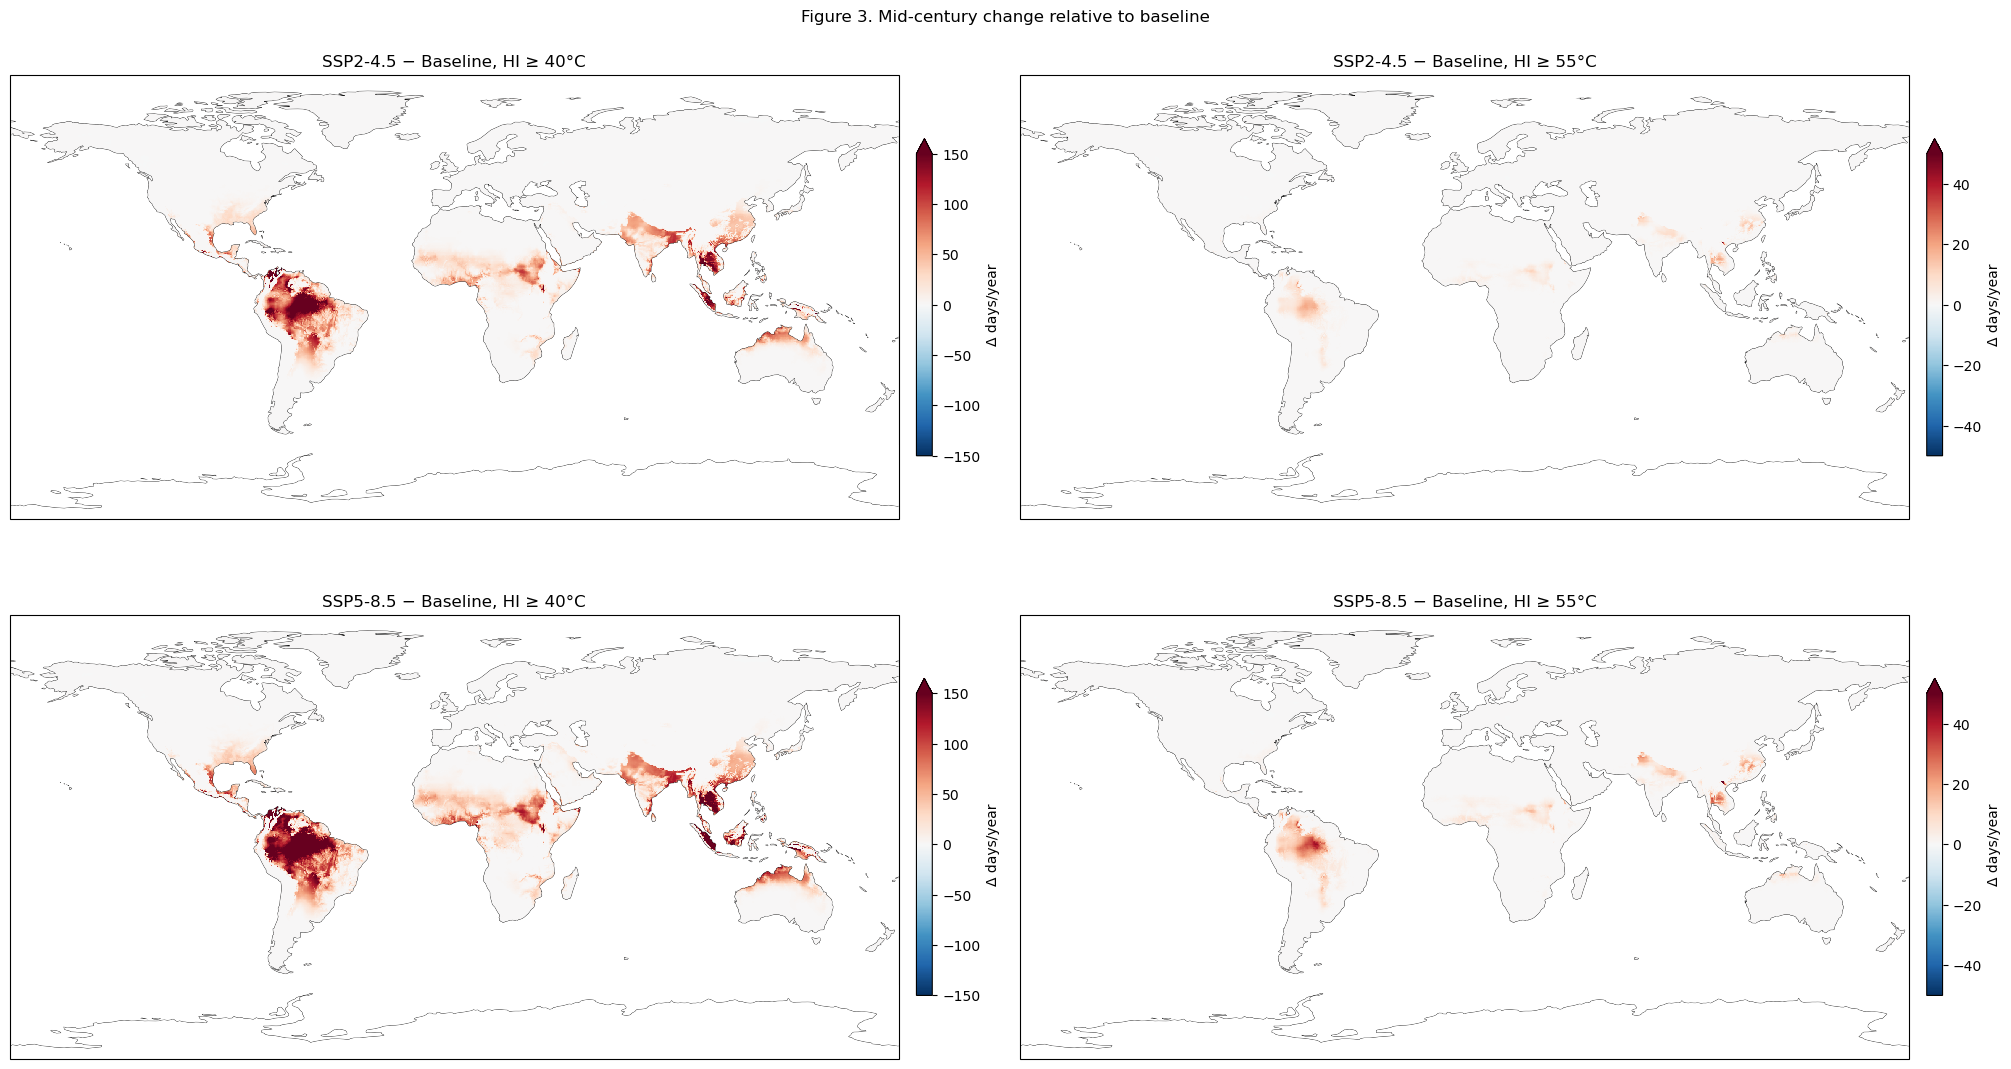

In [26]:
# Figure 3: mid-century minus baseline (Δ days/year)
fig, axes = plt.subplots(2, 2, figsize=(20, 11),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)

for r, (label, ds) in enumerate([("SSP2-4.5", mid_245), ("SSP5-8.5", mid_585)]):
    for c, t in enumerate([40, 55]):
        delta = ds[f"days_HI_ge_{t}_mean"] - baseline[f"days_HI_ge_{t}_mean"]
        vmax = 150 if t == 40 else 50
        delta.plot(ax=axes[r, c], transform=ccrs.PlateCarree(),
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   cbar_kwargs={"label": "Δ days/year", "orientation": "vertical", "shrink": 0.6, "pad":0.02})
        axes[r, c].add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
        axes[r, c].coastlines(linewidth=0.5)
        axes[r, c].set_global()
        axes[r, c].set_title(f"{label} − Baseline, HI ≥ {t}°C")

plt.suptitle("Figure 3. Mid-century change relative to baseline")
plt.show()

### Figure 4: End-of-century Heat Index exceedance (2080–2100)
Multi-model mean exceedance maps for the late 21st century, again under SSP2-4.5 and SSP5-8.5.

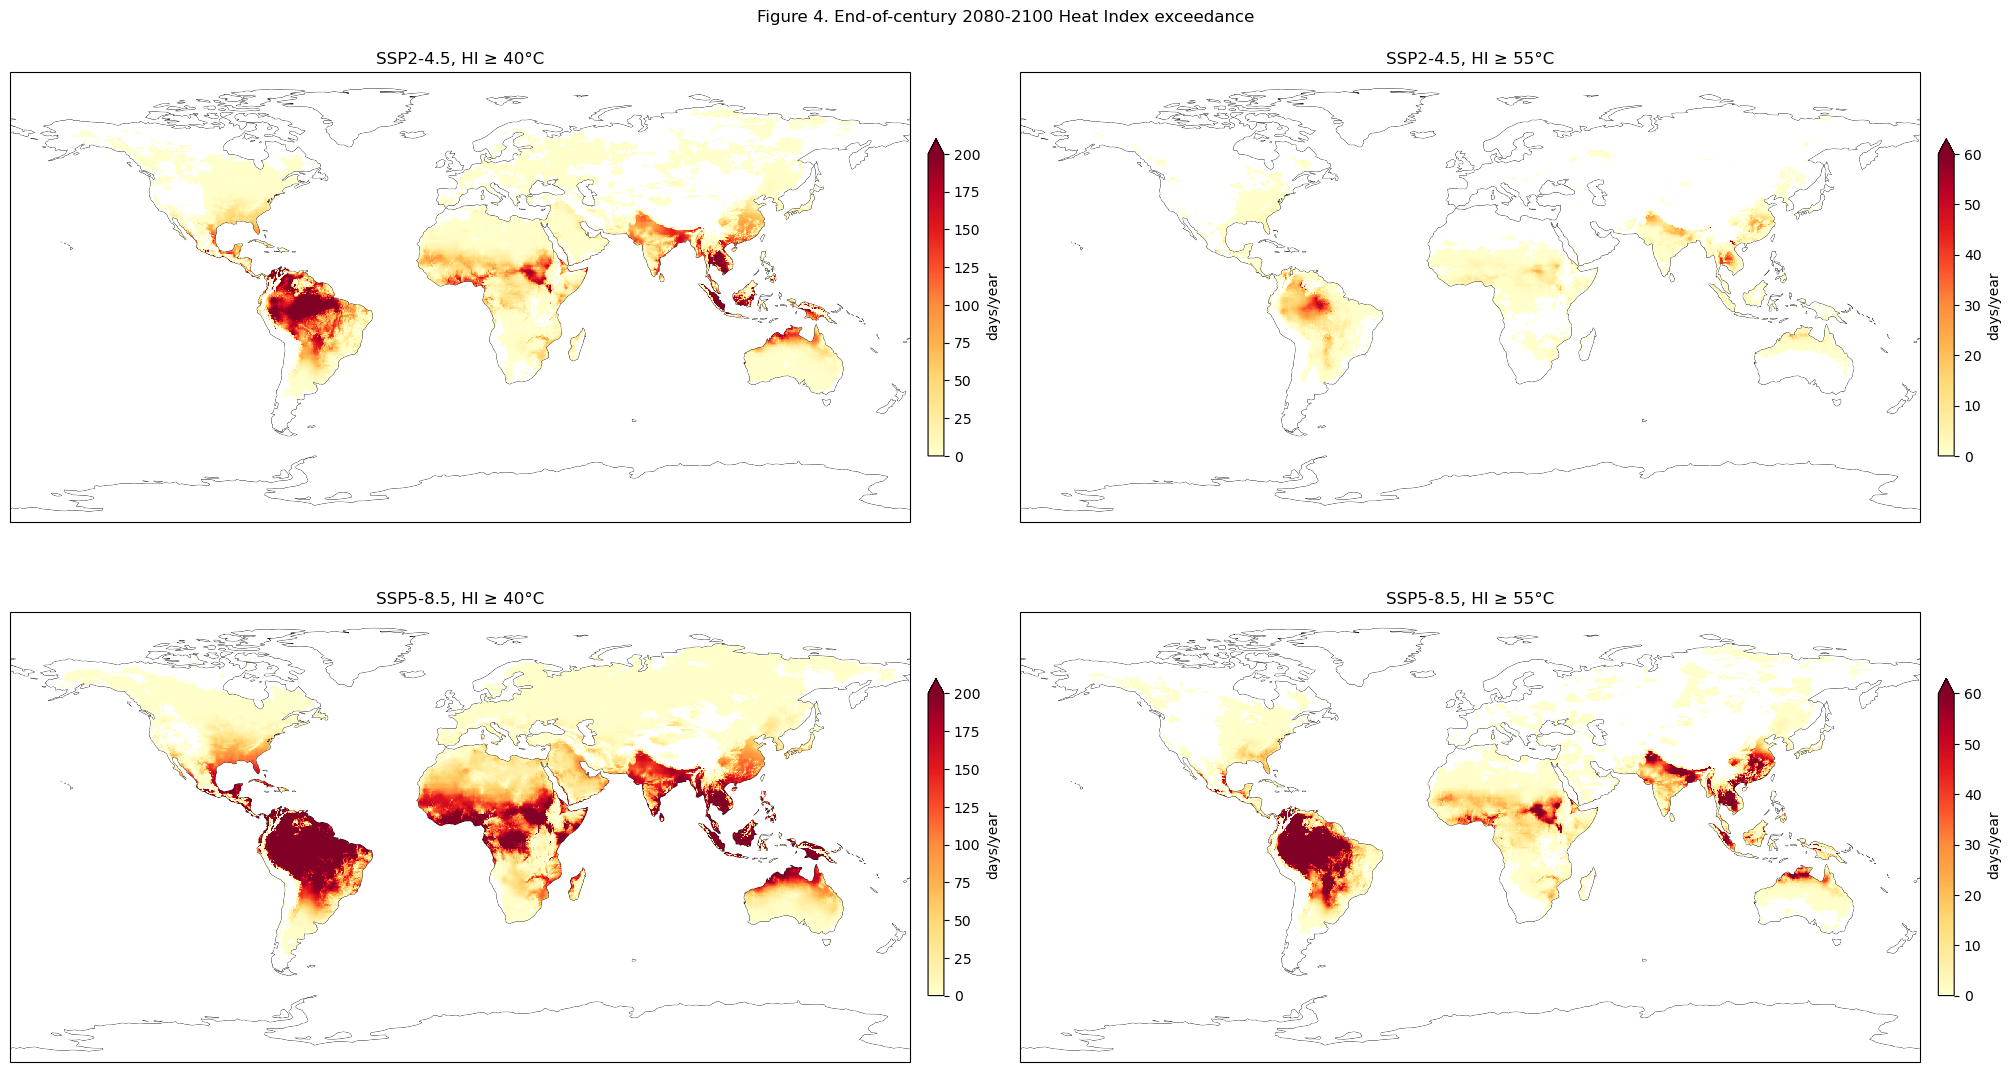

In [29]:
# Figure 4: end-of-century 2080-2100 absolute days/year

import glob
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

y0, y1 = 2080, 2100

files_245 = sorted(glob.glob(f"Final_project/output_simple/*_ssp245_{y0}-{y1}.nc"))
ref = xr.open_dataset(files_245[0])
runs_245 = []
for f in files_245:
    ds = xr.open_dataset(f)
    ds = ds.interp(lat=ref.lat, lon=ref.lon)
    runs_245.append(ds)
end_245 = xr.concat(runs_245, dim="model").mean("model")

files_585 = sorted(glob.glob(f"Final_project/output_simple/*_ssp585_{y0}-{y1}.nc"))
ref = xr.open_dataset(files_585[0])
runs_585 = []
for f in files_585:
    ds = xr.open_dataset(f)
    ds = ds.interp(lat=ref.lat, lon=ref.lon)
    runs_585.append(ds)
end_585 = xr.concat(runs_585, dim="model").mean("model")

fig, axes = plt.subplots(2, 2, figsize=(20, 11),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)

for r, (label, ds) in enumerate([("SSP2-4.5", end_245), ("SSP5-8.5", end_585)]):
    for c, t in enumerate([40, 55]):
        da = ds[f"days_HI_ge_{t}_mean"]
        da = da.where(da > 0)
        vmax = 200 if t == 40 else 60
        da.plot(ax=axes[r, c], transform=ccrs.PlateCarree(),
                cmap="YlOrRd", vmin=0, vmax=vmax,
                cbar_kwargs={"label": "days/year", "orientation": "vertical", "shrink": 0.6, "pad":0.02})
        axes[r, c].add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
        axes[r, c].coastlines(linewidth=0.5)
        axes[r, c].set_global()
        axes[r, c].set_title(f"{label}, HI ≥ {t}°C")

plt.suptitle("Figure 4. End-of-century 2080-2100 Heat Index exceedance")
plt.show()

### Figure 5: End-of-century change in Heat Index exceedance relative to baseline
Difference (end-of-century minus historical baseline) under each SSP scenario, showing the full projected emergence of new dangerously-hot regions by the end of the 21st century.

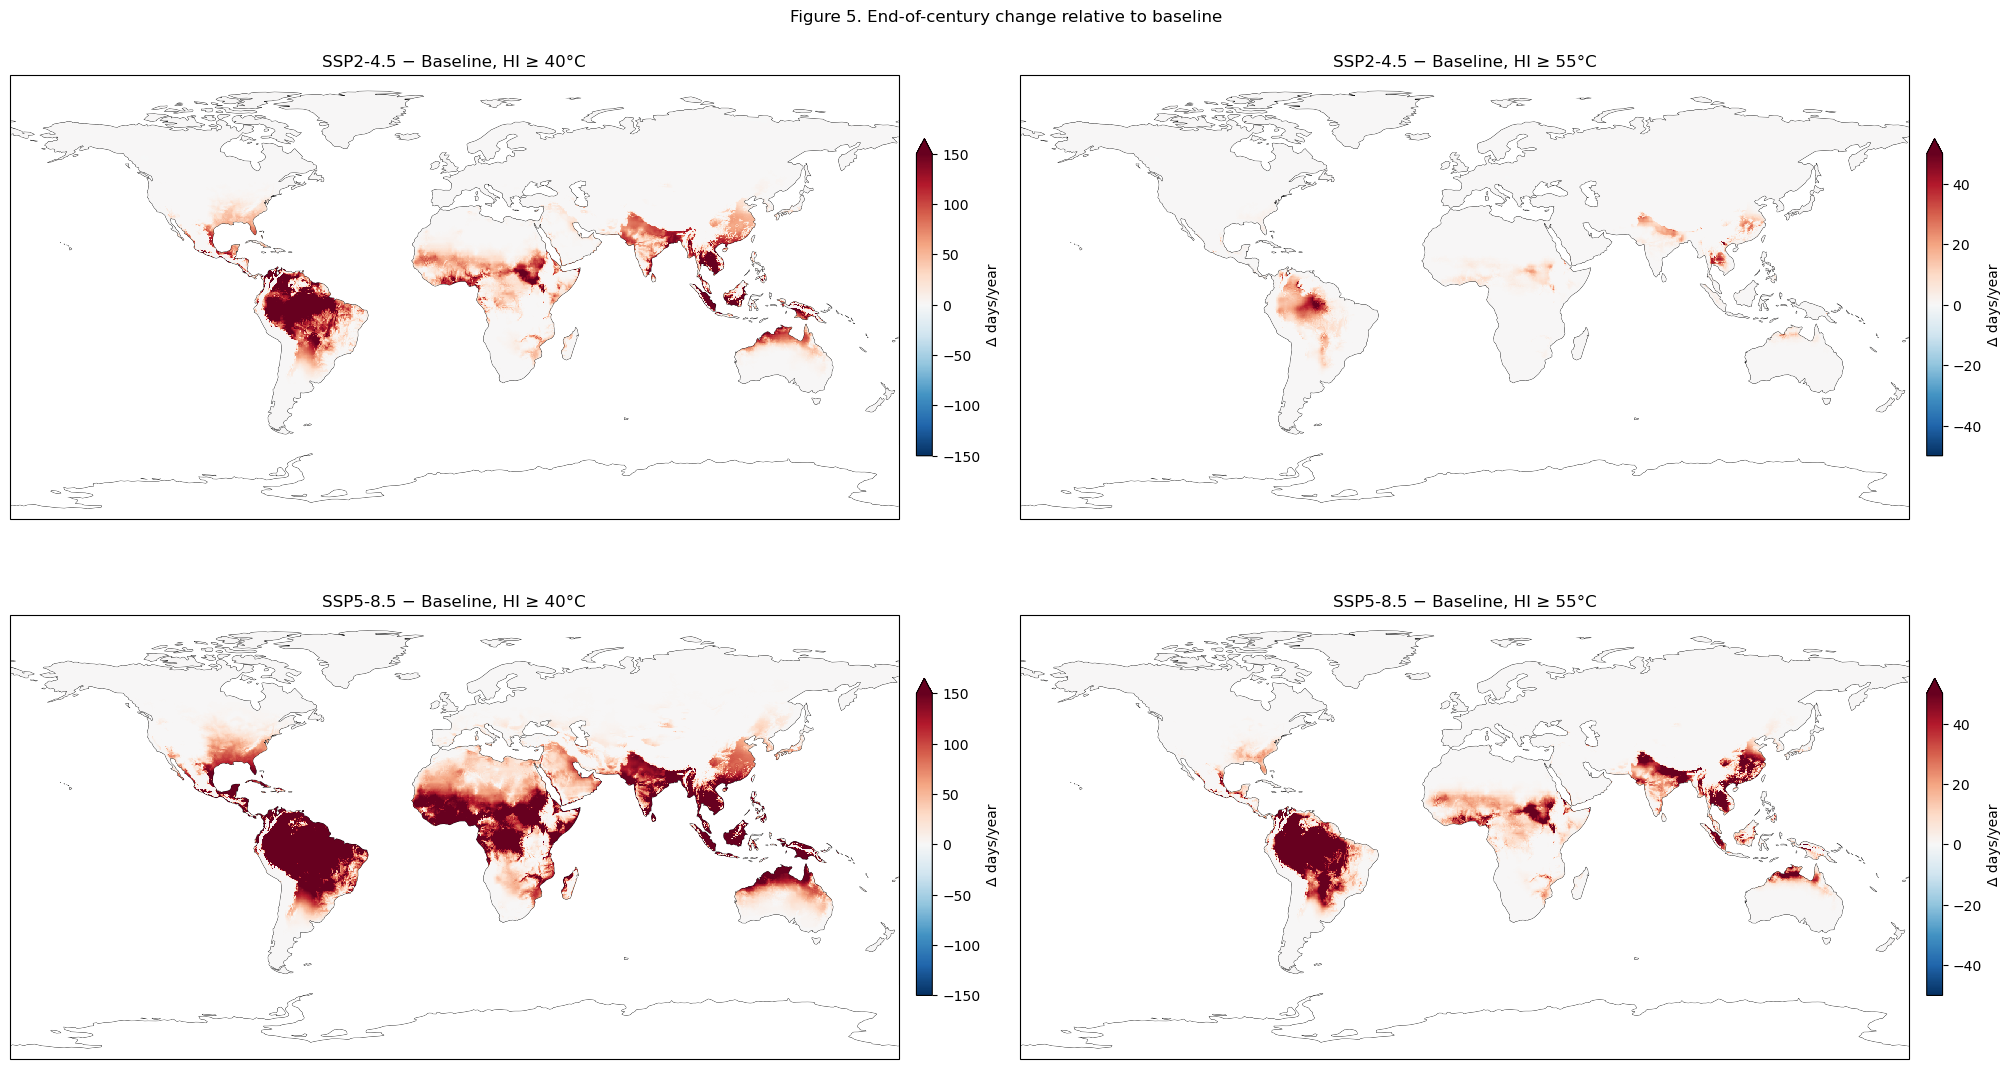

In [30]:
# Figure 5: end-of-century minus baseline (Δ days/year)

fig, axes = plt.subplots(2, 2, figsize=(20, 11),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)

for r, (label, ds) in enumerate([("SSP2-4.5", end_245), ("SSP5-8.5", end_585)]):
    for c, t in enumerate([40, 55]):
        delta = ds[f"days_HI_ge_{t}_mean"] - baseline[f"days_HI_ge_{t}_mean"]
        vmax = 150 if t == 40 else 50
        delta.plot(ax=axes[r, c], transform=ccrs.PlateCarree(),
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   cbar_kwargs={"label": "Δ days/year", "orientation": "vertical", "shrink": 0.6, "pad":0.02})
        axes[r, c].add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
        axes[r, c].coastlines(linewidth=0.5)
        axes[r, c].set_global()
        axes[r, c].set_title(f"{label} − Baseline, HI ≥ {t}°C")

plt.suptitle("Figure 5. End-of-century change relative to baseline")
plt.show()

## Future Risk of Humid Heat

The results highlight the future emergence and expansion of humid heat risk across many densely populated regions, including South Asia, Southeast Asia, West Africa, Central America, and parts of tropical South America. These regions are not only physically favorable for humid heat, but also contain large populations that may be exposed to more frequent dangerous heat-stress conditions. The Heat Index is useful here because it captures the combined effect of air temperature and relative humidity, making it more closely linked to health-relevant heat stress than temperature alone. As Russo et al. (2017) explain, apparent temperature, often referred to as Heat Index, is a nonlinear measure of temperature and relative humidity, and humidity matters because it limits evaporative cooling from the human body.

### Historical baseline

The historical baseline shows that dangerous Heat Index conditions are already concentrated in tropical and some subtropical regions. Days exceeding the 40°C threshold appear most clearly across the Amazon Basin, Central America, West and Central Africa, South Asia, Southeast Asia, and northern Australia. These are not necessarily the world’s hottest dry-bulb temperature regions, but they are places where humidity can substantially amplify apparent temperature.

This baseline pattern is broadly consistent with previous humid-heat studies. Raymond et al. (2020) show that extreme humid heat is highly localized in space and time, with major hotspots in South Asia, the coastal Middle East, coastal southwest North America, eastern coastal India, Pakistan and northwestern India, and other moisture-rich subtropical regions. Their results emphasize that the most severe humid heat tends to occur where intense heat coincides with strong moisture supply, especially near coastlines, shallow seas, monsoon regions, or other sources of atmospheric moisture. In contrast, exceedances of the 55°C threshold are rare in the baseline period, indicating that the most severe category of Heat Index risk was still spatially limited in the mid-20th century climate.

### Changes in the frequency of dangerous Heat Index days

The clearest signal is the increase in the number of days exceeding dangerous Heat Index thresholds. For the 40°C threshold, increases are widespread across the humid tropics and subtropics, especially the Amazon Basin, Central America, West Africa, South Asia, Southeast Asia, and northern Australia. These increases appear by mid-century under both SSP2-4.5 and SSP5-8.5, but become much larger and more spatially extensive by 2080–2100, particularly under SSP5-8.5.

The 55°C threshold shows a less widespread but more severe frequency signal. Unlike the 40°C threshold, which is already present in several tropical regions, days above 55°C remain rare in the historical baseline. However, by the end of the century, SSP5-8.5 produces clear increases in parts of the Amazon Basin, West Africa, South Asia, Southeast Asia, and northern Australia. This means that future warming does not only increase the frequency of already dangerous humid heat; in some regions, it also creates the unprecedented extreme-danger Heat Index conditions.

The spatial pattern of these frequency changes reflects the role of humidity in amplifying heat stress. Dry regions may have very high air temperatures, but low humidity limits Heat Index amplification. In contrast, tropical and monsoon regions already contain abundant atmospheric moisture, so additional warming can translate into stronger human-perceived heat stress. 

### Spatial emergence of severe humid heat

Beyond frequency changes, the maps show where severe humid heat emerges most clearly. The fastest and strongest emergence occurs in humid tropical, coastal, and monsoon-influenced regions, including South Asia, Southeast Asia, West Africa, the Amazon Basin, Central America, and northern Australia. These regions are physically favorable for humid heat because high background moisture can combine with warming to produce large increases in Heat Index.

This emergence pattern is consistent with Raymond et al. (2020, 2021), who emphasize that extreme humid heat often occurs where strong low-level moisture supply overlaps with intense heat and atmospheric conditions that allow heat and moisture to accumulate near the surface. Raymond et al. (2021) identify regions such as the Persian Gulf, north-central Pakistan, eastern South Asia, and the western Amazon as humid-heat hotspots. Several of these hotspot types are also reflected in this analysis, especially South Asia, Southeast Asia, the western Amazon, West Africa, northern Australia, and coastal or monsoon-influenced regions.

The emergence of 55°C Heat Index days is especially important from an exposure perspective. Several regions where this threshold begins to appear, including South Asia, Southeast Asia, and West Africa, are densely populated. As a result, the emergence of extreme-danger humid heat is not only a physical climate signal; it also indicates where larger populations may become exposed to life-threatening heat-stress conditions, particularly in places where high humidity already limits the body’s ability to cool through evaporation.  

### Conclusion
Taken together, the maps show that future humid-heat risk is geographically concentrated and could cause significant impact due to concentrating in densely populated regions. The main increases occur in warm and humid regions where additional warming can sharply raise Heat Index exceedance days. This supports the use of Heat Index as a more human-relevant metric than temperature alone, especially for tropical, coastal, and monsoon regions.

## References

Raymond, C., Matthews, T., & Horton, R. M. (2020). The emergence of heat and humidity too severe for human tolerance. *Science Advances, 6*(19), eaaw1838. https://doi.org/10.1126/sciadv.aaw1838

Raymond, C., Matthews, T., Horton, R. M., Fischer, E. M., Fueglistaler, S., Ivanovich, C., Suarez-Gutierrez, L., & Zhang, Y. (2021). On the controlling factors for globally extreme humid heat. *Geophysical Research Letters, 48*(23), e2021GL096082. https://doi.org/10.1029/2021GL096082

Russo, S., Sillmann, J., & Sterl, A. (2017). Humid heat waves at different warming levels. *Scientific Reports, 7*, 7477. https://doi.org/10.1038/s41598-017-07536-7